In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('train_apps.csv',sep=',')
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145241 entries, 0 to 145240
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   front_id                           145241 non-null  int64  
 1   decision_day                       145241 non-null  object 
 2   loan_amount_last                   145241 non-null  float64
 3   overdraft_limit_min                145241 non-null  float64
 4   overdraft_limit_max                145241 non-null  float64
 5   offered_rate                       145241 non-null  float64
 6   cb_rate                            145241 non-null  float64
 7   corp_credit_products               94053 non-null   float64
 8   sum_deb_ul_90                      91130 non-null   float64
 9   sum_deb_ul_30                      83788 non-null   float64
 10  cnt_deb_loan_90                    113783 non-null  float64
 11  cnt_deb_ul_ip_90                   1149

front_id                               int64
decision_day                          object
loan_amount_last                     float64
overdraft_limit_min                  float64
overdraft_limit_max                  float64
offered_rate                         float64
cb_rate                              float64
corp_credit_products                 float64
sum_deb_ul_90                        float64
sum_deb_ul_30                        float64
cnt_deb_loan_90                      float64
cnt_deb_ul_ip_90                     float64
cnt_deb_ul_ip_30                     float64
balance_rur_amt_30_min               float64
cnt_cred_loan_90                     float64
loan_rev_max_start_non_fin           float64
loan_rev_min_start_fin               float64
app_term_mean_360                    float64
overdraft_app_term_max_360           float64
days_from_authperson_registration    float64
fl_hdb_bki_total_active_products     float64
corp_list                            float64
count_all_

In [ ]:
df.head(2)

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0


In [ ]:
y=df['target_value']
y.value_counts()

target_value
0    136395
1      8846
Name: count, dtype: int64

In [ ]:
X_features_str=df[['db_group_last']]
X_features_str.value_counts()
X_features_str_db_group_last=df[['db_group_last']].fillna('Unknown')
Encoder=OneHotEncoder(drop='first',handle_unknown='ignore')
Encoder.fit(X_features_str_db_group_last)
X_features_str_db_group_last=Encoder.transform(X_features_str_db_group_last)
table_db_group_last=pd.DataFrame.sparse.from_spmatrix(data=X_features_str_db_group_last,columns=Encoder.get_feature_names_out())
table_db_group_last


,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0,0,0,0,1.0,0,0,0,0
1,0,0,0,1.0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
145236,0,0,0,0,0,0,0,0,1.0
145237,0,0,0,1.0,0,0,0,0,0
145238,0,0,0,1.0,0,0,0,0,0
145239,0,0,0,1.0,0,0,0,0,0


In [ ]:
X_features_str_fl_adminarea=df[['fl_adminarea']]
X_features_str_fl_adminarea.value_counts()
X_features_str_fl_adminarea=X_features_str_fl_adminarea[['fl_adminarea']].fillna('Unknown')
Encoder_f1=OneHotEncoder(drop='first',handle_unknown='ignore')
Encoder_f1.fit(X_features_str_fl_adminarea)
X_features_str_fl_adminarea=Encoder_f1.transform(X_features_str_fl_adminarea)
X_features_str_fl_adminarea
table_fl_adminarea=pd.DataFrame.sparse.from_spmatrix(X_features_str_fl_adminarea,columns=Encoder_f1.get_feature_names_out())
table_fl_adminarea


,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,fl_adminarea_Брянская область,fl_adminarea_Владимирская область,fl_adminarea_Волгоградская область,fl_adminarea_Вологодская область,fl_adminarea_Воронежская область,...,fl_adminarea_Хабаровский край,fl_adminarea_Ханты-Мансийский автономный окр.,fl_adminarea_Челябинская область,fl_adminarea_Чеченская Республика,fl_adminarea_Чувашская Республика - Чувашия,fl_adminarea_Ямало - Ненецкий автономный округ,fl_adminarea_Ярославская область,fl_adminarea_г. Москва,fl_adminarea_г. Санкт - Петербург,fl_adminarea_г. Севастополь
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
145237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
145238,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,0
145239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


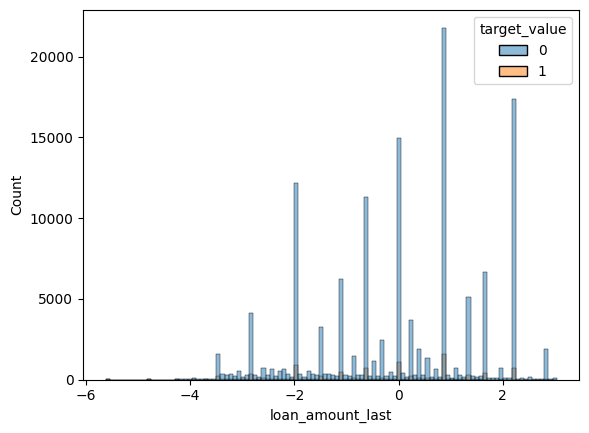

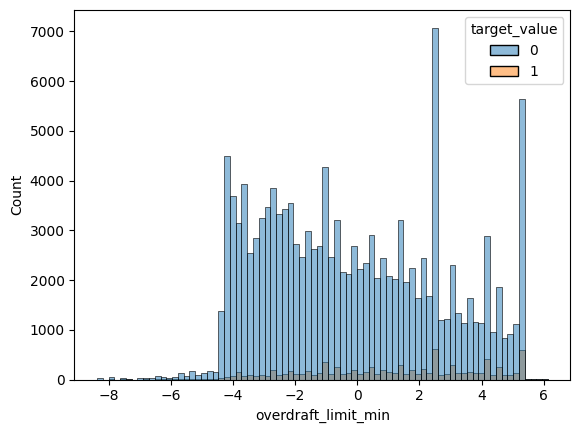

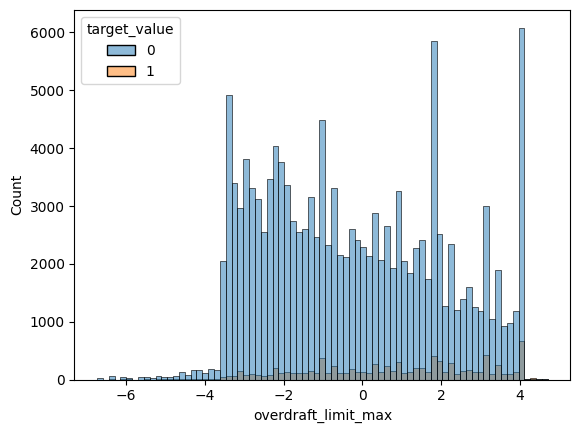

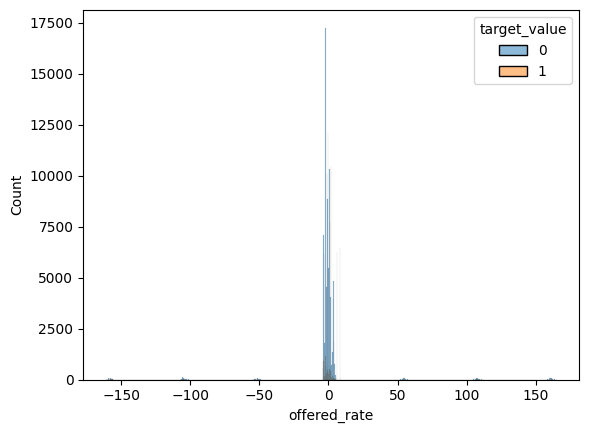

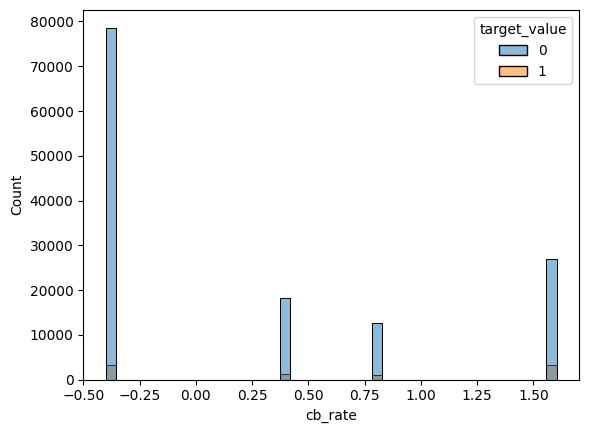

In [ ]:
X=df[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']]
features = ['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']
for col in features:
    sns.histplot(data=df,x=col,hue='target_value')
    plt.show()

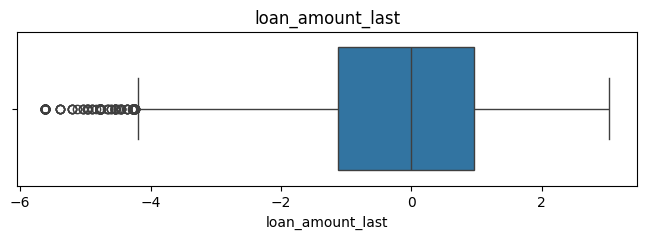

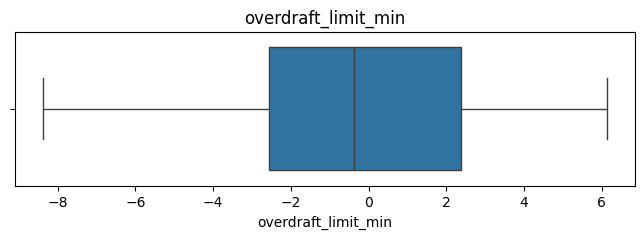

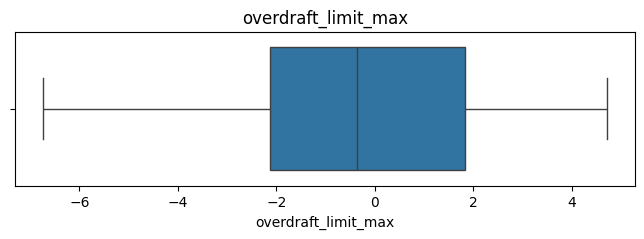

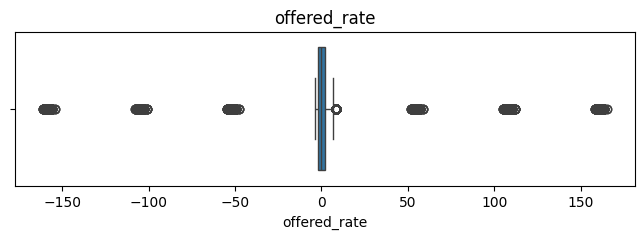

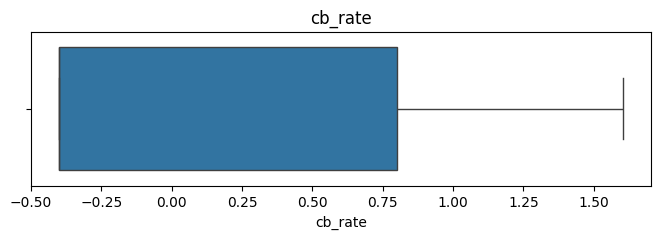

In [ ]:
for col in features:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
X['offered_rate'].describe()

count    145241.000000
mean          0.451652
std          17.085141
min        -161.117698
25%          -2.129309
50%          -0.177442
75%           1.774424
max         165.021431
Name: offered_rate, dtype: float64

In [ ]:
X.nlargest(10, 'offered_rate')

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate
143345,0.000000,4.818964,3.672648,165.021431,1.602779
143408,1.339991,2.480726,1.828130,165.021431,1.602779
142172,2.185431,-1.409040,-1.240309,163.601892,1.602779
142292,1.339991,1.296648,0.894072,163.601892,1.602779
142293,-1.468500,-1.430141,-1.256954,163.601892,1.602779
142358,2.185431,-2.742346,-2.292086,163.601892,1.602779
142368,-1.468500,-3.778433,-3.109402,163.601892,1.602779
142421,0.000000,-0.420351,-0.460382,163.601892,1.602779
142473,0.000000,1.124621,0.758368,163.601892,1.602779
142595,0.845440,-0.679050,-0.664457,163.601892,1.602779


In [ ]:
X.nsmallest(10, 'offered_rate')

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate
132266,1.690880,4.174477,3.164245,-161.117698,1.602779
132566,0.000000,2.190755,3.982505,-161.117698,1.602779
132976,0.845440,5.133295,3.982505,-161.117698,1.602779
133272,2.808491,5.211760,3.982505,-161.117698,1.602779
133864,-1.117611,-0.011313,0.166022,-161.117698,1.602779
138742,2.185431,5.211760,3.982505,-161.117698,1.602779
131640,0.845440,2.986894,2.227421,-160.762813,1.602779
131709,0.000000,3.803507,2.871605,-160.762813,1.602779
131842,2.808491,5.211760,3.982505,-160.762813,1.602779
131941,0.845440,4.145626,3.141486,-160.762813,1.602779


In [ ]:
X = X.copy()
X['offered_rate'] = X['offered_rate'].mask(X['offered_rate'] < -50,-9999)
X['offered_rate'] = X['offered_rate'].mask(X['offered_rate'] > 50,9999)
X['offered_rate'].describe()

count    145241.000000
mean          6.165663
std        1438.483661
min       -9999.000000
25%          -2.129309
50%          -0.177442
75%           1.774424
max        9999.000000
Name: offered_rate, dtype: float64

In [ ]:
X['loan_amount_last'].describe()

count    145241.000000
mean          0.007895
std           1.566315
min          -5.616959
25%          -1.117611
50%           0.000000
75%           0.961691
max           3.030871
Name: loan_amount_last, dtype: float64

In [ ]:
X['cb_rate'].describe()

count    145241.000000
mean          0.236037
std           0.806974
min          -0.400695
25%          -0.400695
50%          -0.400695
75%           0.801389
max           1.602779
Name: cb_rate, dtype: float64

In [ ]:
X['cb_rate'].value_counts()

cb_rate
-0.400695    81991
 1.602779    30225
 0.400695    19402
 0.801389    13623
Name: count, dtype: int64

In [ ]:
X['overdraft_limit_max'].describe()

count    145241.000000
mean         -0.152180
std           2.272220
min          -6.738516
25%          -2.121539
50%          -0.366457
75%           1.828130
max           4.708039
Name: overdraft_limit_max, dtype: float64

In [ ]:
X['overdraft_limit_min'].describe()

count    145241.000000
mean         -0.079469
std           2.859922
min          -8.378948
25%          -2.560781
50%          -0.379964
75%           2.368351
max           6.131498
Name: overdraft_limit_min, dtype: float64

In [ ]:
X_features_after=pd.concat([X,table_fl_adminarea,table_db_group_last],axis=1)
X_features_after['offered_rate'].describe()


count    145241.000000
mean          6.165663
std        1438.483661
min       -9999.000000
25%          -2.129309
50%          -0.177442
75%           1.774424
max        9999.000000
Name: offered_rate, dtype: float64

In [ ]:
# scaler=StandardScaler()
# labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate']
# for i in labels_features:
#    X_features_after[i]=scaler.fit_transform(X_features_after[[i]])
X_features_after




,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,0,0,0,0,0,...,0,0,0,0,0,1.0,0,0,0,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
145237,0.845440,3.639458,3.605443,1.596982,1.602779,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
145238,1.690880,3.960429,2.995393,3.903733,1.602779,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0


In [ ]:

from sklearn.model_selection import train_test_split
X_features_after = X_features_after.astype(float)
X_train,X_test,y_train,y_test=train_test_split(X_features_after,y,test_size=0.3)
scaler=StandardScaler()
# scaler.fit(X_train)
# X_train=scaler.transform(X_train)
# X_test=scaler.transform(X_test)
labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate']
for i in labels_features:
    scaler.fit(X_train[[i]])
    X_train[i]=scaler.transform(X_train[[i]])
    X_test[i]=scaler.transform(X_test[[i]])
X_train


,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
91948,-1.971603,-1.142432,-1.151318,-1.419539,0.202647,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95916,-0.002576,-0.037264,-0.054221,-0.354885,0.202647,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35013,0.537793,0.982314,0.957911,-0.709770,-0.789061,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13303,-0.716905,-1.382475,-1.389608,3.548848,-0.789061,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
136655,-0.002576,1.017200,0.992543,-0.177442,1.690209,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108014,0.537793,0.704829,0.682453,-0.709770,0.698501,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
142194,-0.400810,-0.905398,-0.916014,1.596982,1.690209,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128647,1.078163,-1.692863,-1.697729,1.596982,1.690209,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
26385,0.139560,-1.076219,-1.085588,3.548848,-0.789061,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
parameters=parameters = {
    'loss': ['log_loss', 'exponential'],
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'max_depth': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
    
}
Boost=RandomizedSearchCV(GradientBoostingClassifier(),parameters)
Boost.fit(X_train,y_train)
y_pred_proba = Boost.predict_proba(X_test)[:, 1]
roc_auc_score(y_test,y_pred_proba)


['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_learning_rate',
 'param_loss',
 'param_max_depth',
 'param_max_features',
 'param_n_estimators',
 'param_subsample',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [ ]:
Boost.get_params()
Boost.best_score_
Boost.best_params_

{'subsample': 0.6,
 'n_estimators': 200,
 'max_features': 'sqrt',
 'max_depth': 3,
 'loss': 'exponential',
 'learning_rate': 0.2}

In [ ]:
Boost=GradientBoostingClassifier(subsample=0.6,
 n_estimators=200,
 max_features='sqrt',
 max_depth=3,
 loss='exponential',
 learning_rate=0.2)
Boost.fit(X_train,y_train)
y_pred_proba = Boost.predict_proba(X_test)[:, 1]
roc_auc_score(y_test,y_pred_proba)

0.7482218949844146

In [ ]:
parameters = {
    'loss': ['log_loss', 'exponential'],
    'n_estimators': [100, 200, 500, 110, 130, 125, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.001, 0.003],
    'subsample': [0.6, 0.8, 1.0, 0.3, 0.1],
    'max_depth': [1, 3, 5, 9, 15],
    'max_features': ['sqrt', 'log2']
    
}
Boost=RandomizedSearchCV(GradientBoostingClassifier(),parameters)
Boost.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [1, 3, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [ ]:
Boost.get_params()
Boost.best_score_
Boost.best_params_

{'subsample': 0.3,
 'n_estimators': 150,
 'max_features': 'sqrt',
 'max_depth': 5,
 'loss': 'exponential',
 'learning_rate': 0.1}

In [ ]:
Boost=GradientBoostingClassifier(subsample=0.6,
 n_estimators=150,
 max_features='sqrt',
 max_depth=5,
 loss='exponential',
 learning_rate=0.1)
Boost.fit(X_train,y_train)
y_pred_proba = Boost.predict_proba(X_test)[:, 1]
roc_auc_score(y_test,y_pred_proba)

0.7499196086326079

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
parameters_forest = {
    'n_estimators': [100, 200, 400, 600],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Forest = RandomizedSearchCV(
    RandomForestClassifier(),
    parameters_forest,
    cv=cv,
    n_iter=20,
    random_state=42
)
Forest.fit(X_train,y_train)
y_pred_proba = Forest.predict_proba(X_test)[:, 1]
roc_auc_score(y_test,y_pred_proba)

KeyboardInterrupt: 

In [ ]:
df_test=pd.read_csv('test_apps.csv',sep=',')
df_test.shape

(36311, 27)

In [ ]:
idx= df_test['front_id']

In [ ]:
X_numbers_test=df_test.drop(['decision_day','db_group_last','fl_adminarea'],axis=1)
X_features_str_test=df_test[['db_group_last']]
X_features_str_db_group_last_test=df_test[['db_group_last']].fillna('Unknown')
X_features_str_db_group_last_test=Encoder.transform(X_features_str_db_group_last_test)
table_db_group_last_test=pd.DataFrame.sparse.from_spmatrix(data=X_features_str_db_group_last_test,columns=Encoder.get_feature_names_out())
table_db_group_last_test

,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,0,0,0,1.0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,1.0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,1.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
36306,0,0,0,0,0,0,0,0,0
36307,0,0,0,0,0,0,0,0,0
36308,0,0,0,1.0,0,0,0,0,0
36309,0,0,0,0,0,0,0,0,0


In [ ]:
X_features_str_fl_adminarea_test=df_test[['fl_adminarea']]
X_features_str_fl_adminarea_test=X_features_str_fl_adminarea_test[['fl_adminarea']].fillna('Unknown')
X_features_str_fl_adminarea_test=Encoder_f1.transform(X_features_str_fl_adminarea_test)
table_fl_adminarea_test=pd.DataFrame.sparse.from_spmatrix(X_features_str_fl_adminarea_test,columns=Encoder_f1.get_feature_names_out())
table_fl_adminarea_test

,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,fl_adminarea_Брянская область,fl_adminarea_Владимирская область,fl_adminarea_Волгоградская область,fl_adminarea_Вологодская область,fl_adminarea_Воронежская область,...,fl_adminarea_Хабаровский край,fl_adminarea_Ханты-Мансийский автономный окр.,fl_adminarea_Челябинская область,fl_adminarea_Чеченская Республика,fl_adminarea_Чувашская Республика - Чувашия,fl_adminarea_Ямало - Ненецкий автономный округ,fl_adminarea_Ярославская область,fl_adminarea_г. Москва,fl_adminarea_г. Санкт - Петербург,fl_adminarea_г. Севастополь
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36307,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36309,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_test=df_test[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']]
X_test = X_test.copy()
X_test['offered_rate'] = X_test['offered_rate'].mask(X_test['offered_rate'] < -50,-9999)
X_test['offered_rate'] = X_test['offered_rate'].mask(X_test['offered_rate'] > 50,9999)
X_test['offered_rate'].describe()

count    36311.000000
mean        47.037126
std       4394.732909
min      -9999.000000
25%         -0.354885
50%          0.532327
75%          1.951866
max       9999.000000
Name: offered_rate, dtype: float64

In [ ]:
X_features_after_test=pd.concat([X_test,table_fl_adminarea_test,table_db_group_last_test],axis=1)
X_features_after_test['offered_rate'].describe()

count    36311.000000
mean        47.037126
std       4394.732909
min      -9999.000000
25%         -0.354885
50%          0.532327
75%          1.951866
max       9999.000000
Name: offered_rate, dtype: float64

In [ ]:
X_features_after_test = X_features_after_test.astype(float)
scaler=StandardScaler()
labels_features=['loan_amount_last','overdraft_limit_min','overdraft_limit_max','cb_rate']
for i in labels_features:
    X_features_after_test[i]=scaler.transform(X_features_after_test[[i]])
X_features_after_test

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,fl_adminarea_Алтайский край,fl_adminarea_Амурская область,fl_adminarea_Архангельская область,fl_adminarea_Астраханская область,fl_adminarea_Белгородская область,...,fl_adminarea_г. Севастополь,db_group_last_bk,db_group_last_cc,db_group_last_ebg,db_group_last_inn_scoring,db_group_last_lombard,db_group_last_overdraft,db_group_last_vkl,db_group_last_zalog_bk,db_group_last_zalog_light
0,-0.101977,0.067853,-0.039643,0.709770,2.515267,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.548850,0.457298,0.353930,2.306751,2.515267,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.523635,-1.784579,-1.911713,1.596982,2.515267,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.101977,0.084431,-0.022890,9999.000000,2.515267,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.377020,0.252356,0.146816,3.371406,2.515267,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,1.377020,-0.517815,0.802894,0.177442,-1.011650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36307,1.042331,0.927256,0.828870,9999.000000,-1.011650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36308,0.804866,0.055193,-0.052437,2.484194,-1.011650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
36309,0.383208,0.932300,0.833968,0.177442,-1.011650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_out = pd.DataFrame()
df_out['front_id'] = idx
df_out['target_value'] = Boost.predict_proba(X_features_after_test)[:, 1]

In [ ]:
# df_out.to_csv('submission.csv', index=False)

,value,groups
0,1,cat
1,3,dog
2,5,alhpa
